# Predicción de Series Temporales con MLP
## Cotización Real Brasileño → Boliviano (BRL/BOB)

En este notebook aplicamos un **Perceptrón Multicapa (MLP)** para predecir valores futuros de la cotización BRL/BOB, siguiendo la metodología del notebook de referencia de RNNs.

El flujo será:
1. Carga y preparación del dataset real
2. Creación de ventanas deslizantes (sliding windows)
3. Predicción *Naive* (línea base)
4. Modelo MLP simple
5. Modelo MLP mejorado
6. Comparación de resultados

## 1. Importaciones y Carga del Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

# Semilla para reproducibilidad
np.random.seed(42)
torch.manual_seed(42)

print('Librerías cargadas correctamente.')
print(f'PyTorch versión: {torch.__version__}')

Librerías cargadas correctamente.
PyTorch versión: 2.5.1


In [4]:
# ── Ajusta esta ruta si es necesario ──────────────────────────────────────────
ruta_csv = r'D:\2026\IA-2026-DATASETS\BRL_BOB Historical Data.csv'
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(ruta_csv)

# Nos quedamos con Fecha y Precio de Cierre
df = df[['Date', 'Price']]

# Convertir la columna Date a formato datetime de Pandas
df['Date'] = pd.to_datetime(df['Date'])

# Ordenar cronológicamente (Investing.com entrega los datos al revés)
df = df.sort_values('Date').reset_index(drop=True)

# Asegurarse de que Price sea numérico
if df['Price'].dtype == 'object':
    df['Price'] = df['Price'].str.replace(',', '').astype(float)

print('Tamaño del dataset:', df.shape)
print(df.head())
print('\nRango de fechas:', df['Date'].min(), '→', df['Date'].max())

Tamaño del dataset: (3361, 2)
        Date   Price
0 2015-01-01  2.6134
1 2015-01-02  2.5648
2 2015-01-04  2.5653
3 2015-01-05  2.5491
4 2015-01-06  2.5550

Rango de fechas: 2015-01-01 00:00:00 → 2026-03-13 00:00:00


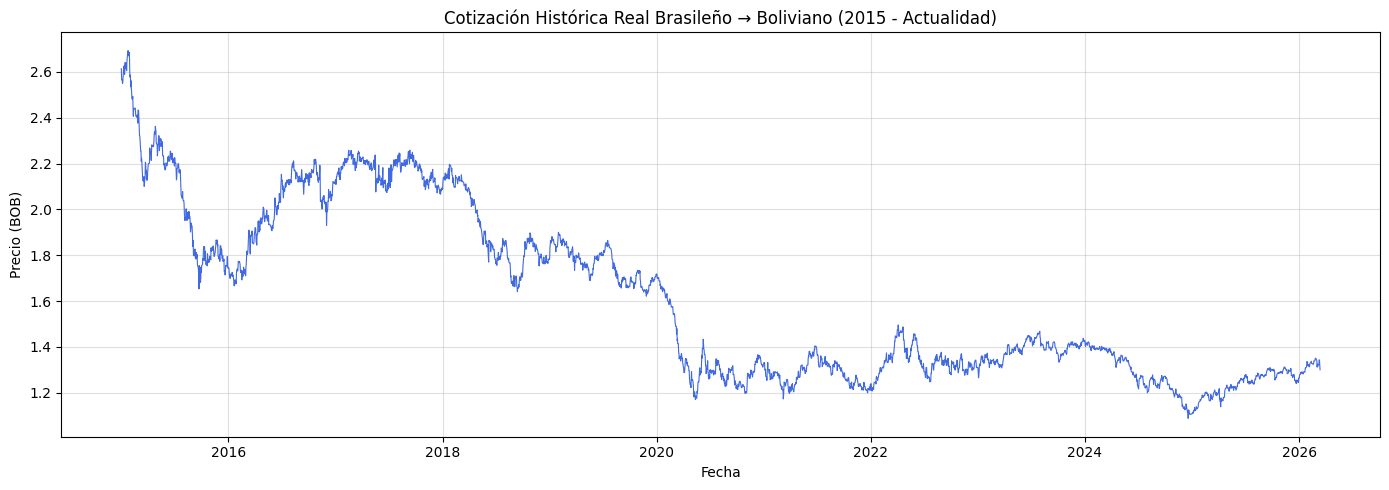

In [5]:
# Gráfico de la serie temporal completa
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Price'], color='royalblue', linewidth=0.8)
plt.title('Cotización Histórica Real Brasileño → Boliviano (2015 - Actualidad)')
plt.xlabel('Fecha')
plt.ylabel('Precio (BOB)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 2. Preparación de la Serie Temporal — Ventanas Deslizantes

Al igual que en el notebook de referencia, nuestro objetivo es:
> Dado los últimos **`n_steps`** precios, predecir el precio del **siguiente día**.

Para ello usamos una técnica de **ventana deslizante** (*sliding window*): recortamos la serie en pequeños fragmentos de longitud `n_steps`, y la etiqueta (`y`) es el valor inmediatamente siguiente.

También **normalizamos** los precios al rango [0, 1] con `MinMaxScaler`, lo que acelera y estabiliza el entrenamiento.

In [6]:
# ── Hiperparámetro: longitud de la ventana ────────────────────────────────────
n_steps = 50   # usamos los últimos 50 días para predecir el día 51
# ─────────────────────────────────────────────────────────────────────────────

# Normalización
precios = df['Price'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
precios_norm = scaler.fit_transform(precios).flatten()

# Construcción de ventanas deslizantes
def crear_ventanas(serie, n_steps):
    """Convierte una serie 1D en pares (X_ventana, y_siguiente)."""
    X, y = [], []
    for i in range(len(serie) - n_steps):
        X.append(serie[i : i + n_steps])
        y.append(serie[i + n_steps])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32).reshape(-1, 1)

X_all, y_all = crear_ventanas(precios_norm, n_steps)
print(f'Total de muestras generadas: {len(X_all)}')
print(f'Forma de X_all: {X_all.shape}   → (muestras, n_steps)')
print(f'Forma de y_all: {y_all.shape}  → (muestras, 1)')

Total de muestras generadas: 3311
Forma de X_all: (3311, 50)   → (muestras, n_steps)
Forma de y_all: (3311, 1)  → (muestras, 1)


In [7]:
# División Train / Validación / Test (70% / 15% / 15%)
n_total  = len(X_all)
n_train  = int(n_total * 0.70)
n_val    = int(n_total * 0.15)

X_train, y_train = X_all[:n_train],          y_all[:n_train]
X_valid, y_valid = X_all[n_train:n_train+n_val], y_all[n_train:n_train+n_val]
X_test,  y_test  = X_all[n_train+n_val:],    y_all[n_train+n_val:]

print(f'Train : {X_train.shape[0]} muestras')
print(f'Valid : {X_valid.shape[0]} muestras')
print(f'Test  : {X_test.shape[0]}  muestras')

Train : 2317 muestras
Valid : 496 muestras
Test  : 498  muestras


## 3. Dataset y DataLoader de PyTorch

Igual que en el ejemplo de referencia, encapsulamos los datos en un `Dataset` personalizado.

In [8]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y=None, train=True):
        self.X     = torch.tensor(X, dtype=torch.float32)
        self.y     = torch.tensor(y, dtype=torch.float32) if y is not None else None
        self.train = train

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        if self.train and self.y is not None:
            return self.X[ix], self.y[ix]
        return self.X[ix]


dataset = {
    'train': TimeSeriesDataset(X_train, y_train, train=True),
    'eval' : TimeSeriesDataset(X_valid, y_valid, train=True),
    'test' : TimeSeriesDataset(X_test,  y_test,  train=False),
}

dataloader = {
    'train': DataLoader(dataset['train'], shuffle=True,  batch_size=64),
    'eval' : DataLoader(dataset['eval'],  shuffle=False, batch_size=64),
    'test' : DataLoader(dataset['test'],  shuffle=False, batch_size=64),
}

print('DataLoaders creados.')
print(f'Batches en train: {len(dataloader["train"])}')

DataLoaders creados.
Batches en train: 37


## 4. Funciones de Entrenamiento y Predicción

Reutilizamos exactamente las mismas funciones `fit` y `predict` del notebook de referencia.

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')


def fit(model, dataloader, epochs=30):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()
    bar = tqdm(range(1, epochs + 1))

    for epoch in bar:
        # ── Fase entrenamiento ──
        model.train()
        train_loss = []
        for batch in dataloader['train']:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss  = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())

        # ── Fase validación ──
        model.eval()
        eval_loss = []
        with torch.no_grad():
            for batch in dataloader['eval']:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss  = criterion(y_hat, y)
                eval_loss.append(loss.item())

        bar.set_description(
            f'loss {np.mean(train_loss):.5f}  val_loss {np.mean(eval_loss):.5f}'
        )


def predict(model, dataloader):
    model.eval()
    with torch.no_grad():
        preds = torch.tensor([]).to(device)
        for batch in dataloader:
            X    = batch.to(device)
            pred = model(X)
            preds = torch.cat([preds, pred])
    return preds


# Función para desnormalizar las predicciones
def desnorm(arr):
    return scaler.inverse_transform(arr.reshape(-1, 1)).flatten()


print('Funciones fit y predict definidas.')

Dispositivo: cuda
Funciones fit y predict definidas.


## 5. Predicción *Naive* (Línea Base)

Igual que en el ejemplo de referencia, empezamos con el modelo más sencillo posible: **predecir el último valor conocido** como siguiente precio.

Este modelo es sorprendentemente competitivo en series financieras con alta autocorrelación.

MSE Naive (escala real): 0.000094


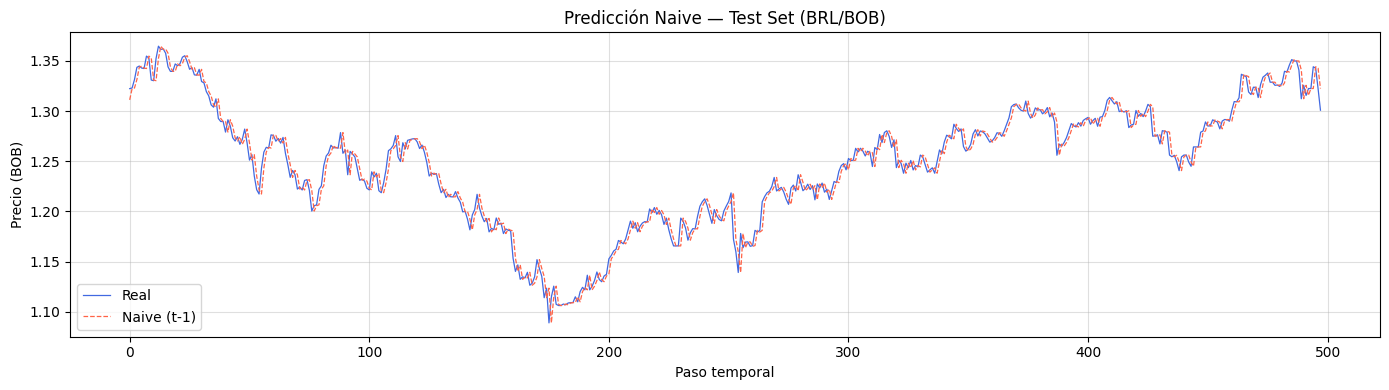

In [10]:
# El modelo Naive predice que mañana = hoy (último valor de la ventana)
y_pred_naive_norm = X_test[:, -1].reshape(-1, 1)  # último paso de cada ventana

# Desnormalizar para calcular MSE en escala real
y_test_real        = desnorm(y_test)
y_pred_naive_real  = desnorm(y_pred_naive_norm)

mse_naive = mean_squared_error(y_test_real, y_pred_naive_real)
print(f'MSE Naive (escala real): {mse_naive:.6f}')

# Visualización
plt.figure(figsize=(14, 4))
plt.plot(y_test_real,       label='Real',          color='royalblue', linewidth=0.9)
plt.plot(y_pred_naive_real, label='Naive (t-1)',   color='tomato',    linewidth=0.9, linestyle='--')
plt.title('Predicción Naive — Test Set (BRL/BOB)')
plt.xlabel('Paso temporal')
plt.ylabel('Precio (BOB)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 6. Modelo MLP Simple

Siguiendo el notebook de referencia, construimos un **MLP con una sola capa lineal** que recibe los `n_steps` valores de entrada y produce 1 valor de salida.

```
Entrada (50) → Linear(50, 1) → Salida (1)
```

In [11]:
class MLPSimple(torch.nn.Module):
    """MLP de una sola capa lineal — idéntico al del notebook de referencia."""
    def __init__(self, n_in=n_steps, n_out=1):
        super().__init__()
        self.fc = torch.nn.Linear(n_in, n_out)

    def forward(self, x):
        x = x.view(x.shape[0], -1)  # aplanar
        return self.fc(x)


mlp_simple = MLPSimple()
print(mlp_simple)
total_params = sum(p.numel() for p in mlp_simple.parameters())
print(f'Parámetros totales: {total_params}')

MLPSimple(
  (fc): Linear(in_features=50, out_features=1, bias=True)
)
Parámetros totales: 51


In [12]:
fit(mlp_simple, dataloader, epochs=30)

loss 0.00044  val_loss 0.00018: 100%|██████████| 30/30 [00:03<00:00,  8.26it/s]


MSE MLP Simple (escala real): 0.000350


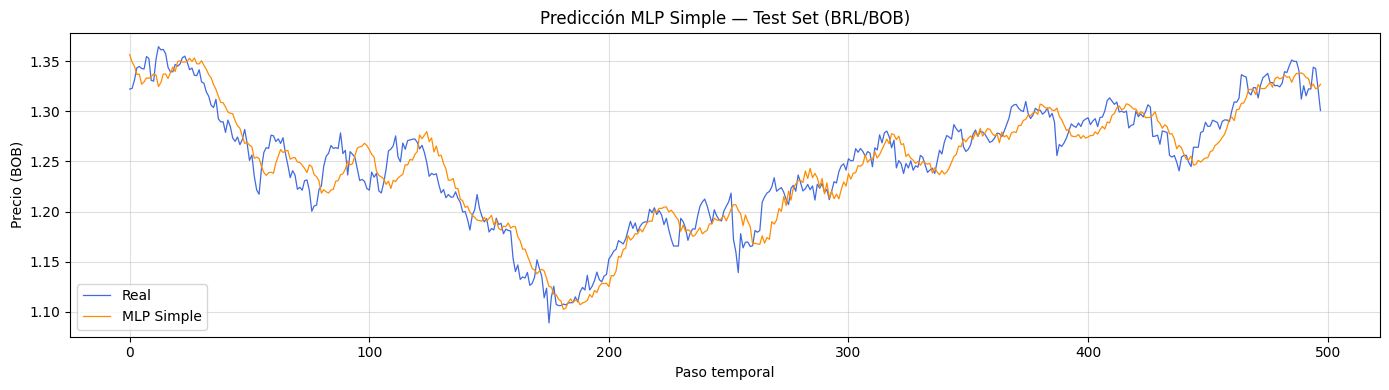

In [13]:
y_pred_simple_norm = predict(mlp_simple, dataloader['test']).cpu().numpy()
y_pred_simple_real = desnorm(y_pred_simple_norm)

mse_simple = mean_squared_error(y_test_real, y_pred_simple_real)
print(f'MSE MLP Simple (escala real): {mse_simple:.6f}')

plt.figure(figsize=(14, 4))
plt.plot(y_test_real,        label='Real',        color='royalblue', linewidth=0.9)
plt.plot(y_pred_simple_real, label='MLP Simple',  color='darkorange', linewidth=0.9)
plt.title('Predicción MLP Simple — Test Set (BRL/BOB)')
plt.xlabel('Paso temporal')
plt.ylabel('Precio (BOB)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 7. Modelo MLP Mejorado

Aumentamos la capacidad del modelo con capas ocultas, activación ReLU y Dropout para regularización.

```
Entrada (50) → Linear(50,128) → ReLU → Dropout(0.2)
            → Linear(128,64)  → ReLU → Dropout(0.2)
            → Linear(64,1)    → Salida (1)
```

In [14]:
class MLPMejorado(torch.nn.Module):
    """MLP con capas ocultas, ReLU y Dropout."""
    def __init__(self, n_in=n_steps, n_out=1):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(n_in, 128),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(128, 64),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(64, n_out),
        )

    def forward(self, x):
        x = x.view(x.shape[0], -1)  # aplanar
        return self.net(x)


mlp_mejor = MLPMejorado()
print(mlp_mejor)
total_params = sum(p.numel() for p in mlp_mejor.parameters())
print(f'Parámetros totales: {total_params}')

MLPMejorado(
  (net): Sequential(
    (0): Linear(in_features=50, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Parámetros totales: 14849


In [15]:
fit(mlp_mejor, dataloader, epochs=50)

loss 0.00121  val_loss 0.00015: 100%|██████████| 50/50 [00:06<00:00,  7.17it/s]


MSE MLP Mejorado (escala real): 0.000365


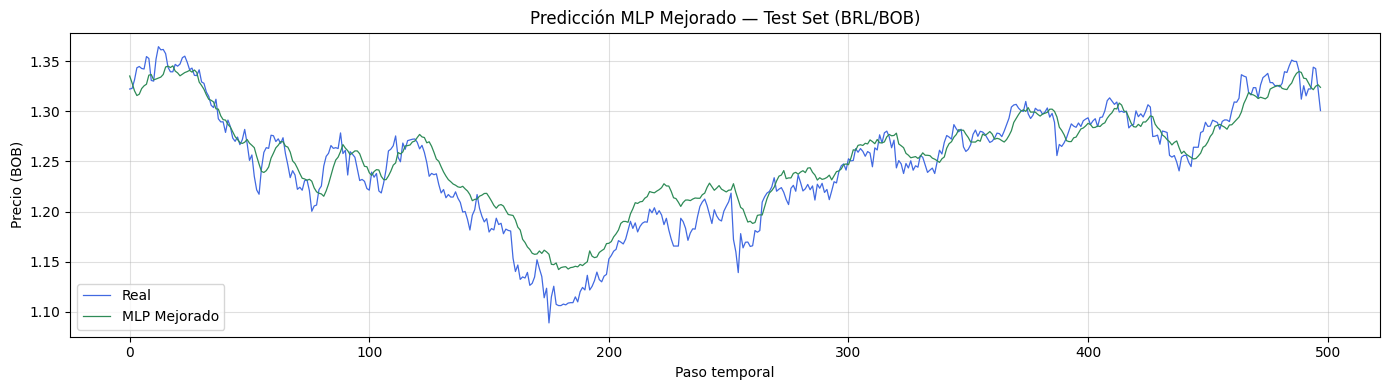

In [16]:
y_pred_mejor_norm = predict(mlp_mejor, dataloader['test']).cpu().numpy()
y_pred_mejor_real = desnorm(y_pred_mejor_norm)

mse_mejor = mean_squared_error(y_test_real, y_pred_mejor_real)
print(f'MSE MLP Mejorado (escala real): {mse_mejor:.6f}')

plt.figure(figsize=(14, 4))
plt.plot(y_test_real,       label='Real',          color='royalblue',  linewidth=0.9)
plt.plot(y_pred_mejor_real, label='MLP Mejorado',  color='seagreen',   linewidth=0.9)
plt.title('Predicción MLP Mejorado — Test Set (BRL/BOB)')
plt.xlabel('Paso temporal')
plt.ylabel('Precio (BOB)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 8. Comparación Final de Modelos

Resumimos el MSE de los tres modelos y graficamos las predicciones superpuestas.

In [17]:
print('=' * 45)
print(f'  Modelo           MSE (escala real BOB²)')
print('=' * 45)
print(f'  Naive (t-1)      {mse_naive:.6f}')
print(f'  MLP Simple       {mse_simple:.6f}')
print(f'  MLP Mejorado     {mse_mejor:.6f}')
print('=' * 45)

  Modelo           MSE (escala real BOB²)
  Naive (t-1)      0.000094
  MLP Simple       0.000350
  MLP Mejorado     0.000365


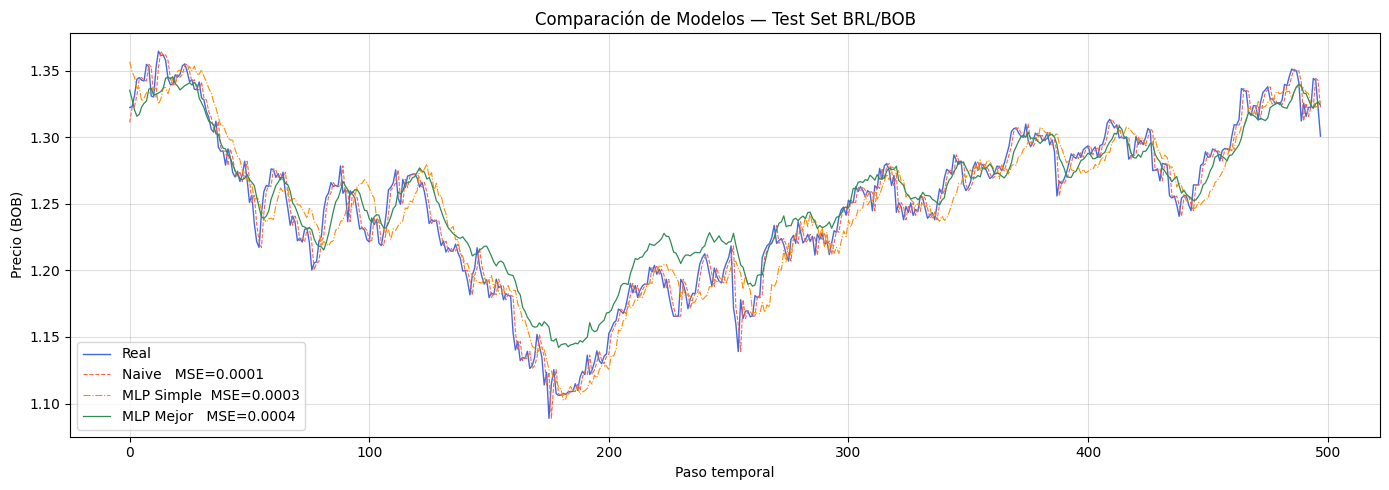

In [18]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_real,        label='Real',          color='royalblue',  linewidth=1.0)
plt.plot(y_pred_naive_real,  label=f'Naive   MSE={mse_naive:.4f}',  color='tomato',     linewidth=0.8, linestyle='--')
plt.plot(y_pred_simple_real, label=f'MLP Simple  MSE={mse_simple:.4f}', color='darkorange', linewidth=0.8, linestyle='-.')
plt.plot(y_pred_mejor_real,  label=f'MLP Mejor   MSE={mse_mejor:.4f}',  color='seagreen',   linewidth=0.9)
plt.title('Comparación de Modelos — Test Set BRL/BOB')
plt.xlabel('Paso temporal')
plt.ylabel('Precio (BOB)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 9. Análisis y Conclusiones

### Diferencia clave respecto al ejemplo sintético

En el notebook de referencia, los datos son **series sinusoidales sintéticas** con patrones muy claros y repetibles. El MLP logra capturarlos con facilidad.

En cambio, la cotización **BRL/BOB es una serie financiera real**, que presenta:
- **Alta autocorrelación de corto plazo** (el precio de hoy es muy similar al de ayer).
- **Cambios de régimen** (caída sostenida 2015–2020, estabilización posterior).
- **Ruido intrínseco** imposible de predecir con cualquier modelo.

Por eso el modelo **Naive suele ser difícil de superar** en series financieras de corto plazo — es un resultado conocido en la literatura de forecasting.

### ¿Qué cambiaríamos para mejorar?

- Aumentar `n_steps` (ventana más larga, más contexto histórico).
- Añadir **features** adicionales (día de la semana, media móvil, RSI).
- Explorar **LSTMs o GRUs** (variantes de RNN diseñadas para dependencias largas).
- Entrenar más épocas con un *learning rate scheduler*.